In [9]:
"""Convert the current full PDBs to Interface PDB as used in UniPPI"""
import os
import pandas as pd
from data.unippi_dataset import GenMutationDataset
from transformers.models.esm.openfold_utils.protein import to_pdb, Protein
from tqdm import tqdm
import diskcache
cache_dir = './cache/TCR_iDist'
data_root = './datasets/TCR-MHC/'
df_path = './datasets/TCR-MHC/splits/TCR_MHC_test.csv'

transform = [{'type': 'select_atom', 'resolution': 'full'}, {'type': 'selected_region_fixed_size_patch', 'select_attr': 'mut_flag', 'patch_size': 128}]
# transform = [{'type': 'select_atom', 'resolution': 'full'}, {'type': 'interface_fixed_size_patch', 'patch_size': 128}]


df = pd.read_csv(df_path)
print("Using diskcache at {}.".format(cache_dir))
cache = diskcache.Cache(directory=cache_dir, eviction_policy='none')

dataset = GenMutationDataset(df, data_root, diskcache=cache, transform=transform)
x = 0
output_root = './datasets/TCR-MHC/PDBs_inter_mut/'
os.makedirs(output_root, exist_ok=True)
pdbs = []
for data in tqdm(dataset):
    # if data['complex_wt']['complex'] in pdbs:
    #     continue
    # else:
    #     pdbs.append(data['complex_wt']['complex'])
    cplx = data['complex_wt']
    filename = cplx['complex'] + '_' + cplx['mutstr'].replace(',', '_') + '.pdb'
    out_dir = os.path.join(output_root, filename)
    aa = cplx["aa"].numpy()
    pred_pos = cplx['atom_pos37'].numpy()
    mask = cplx['atom_mask37'].numpy()
    resid = cplx["resseq"].numpy()
    pred = Protein(
        aatype=aa,
        atom_positions=pred_pos,
        atom_mask=mask,
        residue_index=resid,
        b_factors=mask,
        chain_index=cplx['group_id'], 
    )
    pdb = to_pdb(pred)
    with open(out_dir, 'w') as f:
        f.write(''.join(pdb))
    # break
# print(x)
    # print(i)


Using diskcache at ./cache/TCR_iDist.


 20%|█▉        | 84/423 [00:10<00:51,  6.56it/s]

The data is abnormal: 3pl6 DD56A


100%|██████████| 423/423 [00:55<00:00,  7.58it/s]


In [10]:
"""Methods to measure similarity between protein-protein interactions."""
import os
import itertools
import traceback
import multiprocessing
import concurrent.futures
from abc import ABC
from typing import Iterable, Callable, Literal, Optional, Union
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import sklearn.cluster
from tqdm import tqdm
from graphein.protein.config import ProteinGraphConfig
from graphein.protein.graphs import construct_graph
from graphein.protein.edges.distance import add_k_nn_edges
from graphein.protein.features.nodes.amino_acid import (
    amino_acid_one_hot, meiler_embedding)
from graphein.protein.features.sequence.embeddings import esm_residue_embedding
from graphein.protein.features.sequence.utils import (
    aggregate_feature_over_chains, aggregate_feature_over_residues)


class PPIComparator(ABC):
    def __init__(self,
        max_workers: int = os.cpu_count() - 2,
        parallel_kind: Literal['threads', 'processes'] = 'processes',
        verbose=False
    ):
        """Abstract class for comparing protein-protein interactions (PPIs).

        Args:
            max_workers (int, optional): Number of workers to use for parallel operations (such as
                comparing large sets of PPIs pairwise). Defaults to ``os.cpu_count() - 2``.
            parallel_kind (Literal['threads', 'processes'], optional): Use
                multi-treading or multi-processing for parallel operations. Defaults to 'processes'.
            verbose (bool, optional): If set to True, prints detailed log to the standard output.
                May be useful for debugging. Defaults to False.
        """
        self.max_workers = max_workers
        self.parallel_kind = parallel_kind
        self.verbose = verbose

    def compare(self, ppi0: Path, ppi1: Path) -> dict:
        """Abstract method for comparing two PPIs. Should be implemented in a subclass.

        Args:
            ppi0 (Path): Path to the first .pdb file containing a PPI. It is recommended to use
                the files produced by the ``ppiref.extraction.PPIExtractor`` class.
            ppi1 (Path): Path to the second .pdb file containing a PPI. It is recommended to use
                the files produced by the ``ppiref.extraction.PPIExtractor`` class.

        Returns:
            dict: Dictionary with comparison results.
        """
        raise NotImplementedError()

    def compare_all_against_all(
        self,
        ppis0: Iterable[Path] = None,
        ppis1: Iterable[Path] = None,
        ppi_pairs: Iterable[Iterable[Path]] = None
    ) -> pd.DataFrame:
        """Comparing all PPIs from one set against all PPIs from another set. This method in the
        abstract class is used as a default implementation where all PPI pairs are compared 
        in a data parallel way. A subclass may override this method to provide a more efficient
        implementation.

        Args:
            ppis0 (Iterable[Path], optional): First set of PPI paths. Defaults to None.
            ppis1 (Iterable[Path], optional): Second set of PPI paths. Defaults to None.
            ppi_pairs (Iterable[Iterable[Path]], optional): Pre-defined pairs to compare instead of
                 complete pair-wise comparison of two sets. Defaults to None.

        Returns:
            pd.DataFrame: Data frame with comparison results. The data frame has two columns
            corresponding to pairs of PPI ids, and additional columns with comparison metrics.
        """
        # Parse input
        if ppis0 is not None and ppis1 is not None:
            ppi_pairs = list(itertools.product(ppis0, ppis1))
        elif ppi_pairs is None:
            raise ValueError('Input pairs are not specified.')

        # Compare and store to dataframe
        df = self._execute_task_parallel(
            self.compare, ppi_pairs, desc=f'Comparing PPIs with {self.__class__.__name__}'
        )
        df = pd.DataFrame(df)
        return df

    def _execute_task_parallel(
        self,
        func: Callable,  
        inputs: Iterable,
        kind: str = None,
        desc: str = '',
        chunksize: int = 1000
    ) -> list:
        """Universal method for executing a function in parallel on a set of inputs. The method
        uses either multi-threading or multi-processing depending on the ``self.parallel_kind``
        attribute.

        Args:
            func (Callable): Function to apply to inputs.
            inputs (Iterable): All inputs to apply the function to.
            kind (str, optional): Use multi-threading or multi-processing. Defaults to None to use
                the kind specified in the comparator constructor.
            desc (str, optional): Progress bar description. Defaults to ''.
            chunksize (int, optional): Number of inputs to be processed at a time by a single
                worker. Low chunksize may result into a too large number (e.g. >100K) of jobs for
                workers, which may lead to a significant management overhead. Defaults to 1000.

        Returns:
            List: List of results of applying the function to inputs.
        """
        if kind is None:
            kind = self.parallel_kind
        if kind not in ['threads', 'processes']:
            raise ValueError("Invalid 'kind'. Use 'threads' or 'processes'.")

        executor_class = concurrent.futures.ThreadPoolExecutor if kind == 'threads' else concurrent.futures.ProcessPoolExecutor

        results = []
        futures = []

        with executor_class(max_workers=self.max_workers) as executor:
            total_tasks = len(inputs)
            with tqdm(desc=f'{desc} ({self.max_workers} {kind})', total=total_tasks) as pbar:
                # Submit tasks in chunks to avoid too many simultaneous tasks
                for i in range(0, total_tasks, chunksize):
                    chunk = inputs[i:i + chunksize]
                    for inp in chunk:
                        futures.append(executor.submit(self._unpacked_call, func, inp))

                # Update progress bar as tasks complete
                for future in concurrent.futures.as_completed(futures):
                    try:
                        result = future.result()
                        results.append(result)
                    except Exception as e:
                        print(f"Error occurred: {e}")
                        print(f"Full traceback: {traceback.format_exc()}")
                    finally:
                        pbar.update(1)

        return results
    
    def _unpacked_call(self, func, args):
        """Helper function to unpack arguments for a function call. Used for parallel execution."""
        return func(*args)

IDIST_EMBEDDING_KIND = Literal[
    'amino_acid_one_hot', 'esm_embedding', 'meiler_embedding'
]
   
class IDist(PPIComparator):

    def __init__(
        self,
        kind: IDIST_EMBEDDING_KIND = 'amino_acid_one_hot',
        near_duplicate_threshold: float = 0.04,
        pdb_dir: Optional[Union[str, Path]] = None,
        max_interface_size: int = 1_000_000,
        *args,
        **kwargs
    ):
        """Implementation of `iDist <https://arxiv.org/abs/2310.18515>`_ protein-protein interaction
        comparator used to created the PPIRef dataset.
        
        The comparator uses a simple non-parametrized one-step
        message passing to embed protein-protein interfaces and then compares them using Euclidean
        distance. iDist approximates 3D alignment-based methods, iAlign and US-align, on detecting
        near-duplicate protein-protein interfaces. iDist is more than 100 times faster and finds
        same near duplicates with 99% precision and 97% recall.

        Args:
            kind (IDIST_EMBEDDING_KIND, optional): Kind of node embeddings to use for message
                passing. Defaults to 'amino_acid_one_hot' which leads to the best alignment 
                approximation performance.
            near_duplicate_threshold (float, optional): Threshold on Euclidean distance to detect
                near-duplicate interfaces. It is recommended to use the threshold of 0.04 for the
                interfaces extracted with the 6A cutoff radius between heavy atoms, and the 
                threshold of 0.03 with the 10A cutoff. Please see the paper for details. Defaults
                to 0.04.
            pdb_dir (Optional[Path], optional): Directory storing complete .pdb files that were used
                to exctract interfaces from. Should be not None if ``kind == 'esm_embedding'``, as
                the ESM protein language model is used with full protein sequences. Defaults to None.
            max_interface_size (int, optional): Maximum number of nodes in the interface graph.
        """
        super().__init__(*args, **kwargs)

        # Prepare node features construction
        self.kind = kind
        if kind == 'amino_acid_one_hot':
            dimer_node_metadata_functions = []
            ppi_node_metadata_functions = [amino_acid_one_hot]
        elif kind == 'meiler_embedding':
            dimer_node_metadata_functions = []
            ppi_node_metadata_functions = [meiler_embedding]
        elif kind == 'esm_embedding':
            dimer_node_metadata_functions = []
            ppi_node_metadata_functions = []
        else:
            raise ValueError('Unknown `kind` value.')

        # Init Graphein graph construction config for interfaces (or PPIs)
        self.graphein_ppi_config = ProteinGraphConfig(
            edge_construction_functions=[
                partial(add_k_nn_edges, k=max_interface_size,
                        long_interaction_threshold=0,
                        exclude_edges=['inter'], kind_name='intra'),
                partial(add_k_nn_edges, k=max_interface_size,
                        long_interaction_threshold=0,
                        exclude_edges=['intra'], kind_name='inter')
            ],
            node_metadata_functions=ppi_node_metadata_functions,
            insertions=True
        )

        # Init Graphein graph construction config for complete complexes (or dimers)
        self.graphein_dimer_config = ProteinGraphConfig(
            edge_construction_functions=[],
            node_metadata_functions=dimer_node_metadata_functions,
            insertions=True,
        )

        # Init near-duplicate threshold
        self.near_duplicate_threshold = near_duplicate_threshold

        # Init directory for complete (or dimer) PDB files
        self.pdb_dir = pdb_dir
        if self.pdb_dir is not None:
            self.pdb_dir = Path(self.pdb_dir)
            if not self.pdb_dir.exists():
                self.pdb_dir.mkdir(parents=True, exist_ok=True)

        # Init cache for embeddings
        self.embeddings = dict()

        # Init index for near-duplicate detection
        self.neigh = None

    def compare(
        self,
        path0: Union[Path, str],
        path1: Union[Path, str]
    ) -> dict:
        """Compare two protein-protein interfaces with iDist.

        Args:
            ppi0 (Union[Path, str]): Path to the first .pdb file containing a PPI. It is recommended 
                to use the files produced by the ``ppiref.extraction.PPIExtractor`` class.
            ppi1 (Union[Path, str]): Path to the second .pdb file containing a PPI. It is 
                recommended to use the files produced by the ``ppiref.extraction.PPIExtractor`` 
                class.

        Returns:
            dict: Dictionary with two PPI ids being compared and the resulting iDist distance 
            (Euclidean distance in the embedding space).
        """
        path0, path1 = Path(path0), Path(path1)
        pdb0, pdb1 = path0.stem, path1.stem

        # Encode and compare
        emb0 = self.embed(path0)
        emb1 = self.embed(path1)
        metrics = {
            'iDist': np.linalg.norm(emb0 - emb1),
            # 'L1': np.linalg.norm(emb0 - emb1, ord = 1),
            # 'Cosine Similarity':
            #     np.dot(emb0, emb1) / (np.linalg.norm(emb0) * np.linalg.norm(emb1))
        }

        # Return result dict
        return {'PPI0': pdb0, 'PPI1': pdb1} | metrics

    def compare_all_against_all(
        self,
        ppis0: Iterable[Path] = None,
        ppis1: Iterable[Path] = None,
        ppi_pairs: Iterable[Iterable[Path]] = None,
        embed: bool = True
    ) -> pd.DataFrame:
        """Compare all PPIs from one set against all PPIs from another set efficiently using iDist.

        Args:
            ppis0 (Iterable[Path], optional): First set of PPI paths. Defaults to None.
            ppis1 (Iterable[Path], optional): Second set of PPI paths. Defaults to None.
            ppi_pairs (Iterable[Iterable[Path]], optional): Pre-defined pairs to compare instead of
                complete pair-wise comparison of two sets. Defaults to None.
            embed (bool, optional): If set to True, embeds all PPIs before comparison not to repeat
                same embeddign twice. Defaults to True.

        Returns:
            pd.DataFrame: Data frame with comparison results. The data frame has two columns
            corresponding to pairs of PPI ids, and an additional column with iDist distances.
        """
        # TODO Accelerate with sklearn pairwise
        # Parse input
        if ppis0 is not None and ppis1 is not None:
            ppi_pairs = list(itertools.product(ppis0, ppis1))
        elif ppi_pairs is None:
            raise ValueError('Input pairs are not specified.')

        # Embed PPIs
        if embed:
            if ppis0 is not None and ppis1 is not None:
                ppis = set(ppis0) | set(ppis1)
            else:  # ppi_pairs is not None
                ppis = set(itertools.chain(*ppi_pairs))
            self.embed_parallel(ppis)

        # Compare PPIs pairwise
        df = [self.compare(*x) for x in tqdm(ppi_pairs, desc='Comparing PPIs with iDist')]
        df = pd.DataFrame(df)
        return df

    def embed(self, ppi: Path, store: bool = True) -> np.array:
        """Embed a protein-protein interface.

        Args:
            ppi (Path): Path to the .pdb file containing a PPI. It is recommended to use the files
                produced by the ``ppiref.extraction.PPIExtractor`` class.
            store (bool, optional): Set to True to store the embedding in cache. Defaults to True.

        Returns:
            np.array: PPI interface embedding.
        """
        ppi_id = ppi.stem
        ppi = str(ppi)
        if self.kind == 'esm_embedding':
            dimer = self._ppi_to_pdb(ppi)
            dimer = str(dimer)

        # Get embedding from cache
        if ppi_id in self.embeddings:
            return self.embeddings[ppi_id]

        # Construct interface graph
        g_ppi = construct_graph(
            config=self.graphein_ppi_config, path=ppi, verbose=False
        )
        # print(g_ppi)
        # Construct complete dimer graph and transfer embeddings to interface subgraph if ESM
        # embeddings are used
        if self.kind == 'esm_embedding':
            # Construct protein graph for complete dimer structure
            g_dimer = construct_graph(
                config=self.graphein_dimer_config, pdb_path=dimer,
                chain_selection=''.join(g_ppi.graph['chain_ids']), verbose=False
            )
            # Add ESM residue embeddings to complete-structure graph
            g_dimer = esm_residue_embedding(g_dimer)

            # Transfer node embeddings from complete structure to PPI subgraph
            for n in g_ppi.nodes():
                g_ppi.nodes[n]['esm_embedding'] = \
                    g_dimer.nodes[n]['esm_embedding']
                
        # Rename node features if Meiler embeddings are used
        elif self.kind == 'meiler_embedding':
            for v in g_ppi.nodes():
                g_ppi.nodes[v]['meiler_embedding'] = \
                    g_ppi.nodes[v]['meiler'].values

        # Aggregate neighborhoods (non-parametrized one-step message passing)
        # Note: Can be significantly accelerated via graph-level matmuls
        for v in g_ppi.nodes():
            msg_inter = []
            msg_intra = []
            for n, e in g_ppi[v].items():
                signal = \
                    np.exp(-(e['distance']/4)**2) * g_ppi.nodes[n][self.kind]
                if 'inter' in e['kind']:
                    msg_inter.append(-signal)
                elif 'intra' in e['kind']:
                    msg_intra.append(signal)
            msg_inter = np.mean(msg_inter, axis=0)
            msg_intra = np.mean(msg_intra, axis=0)
            msg = np.mean([msg_inter, msg_intra], axis=0)
            # print("message:", g_ppi.nodes[v][self.kind], msg_inter, msg_intra, msg)
            g_ppi.nodes[v]['embedding'] = np.mean([
                g_ppi.nodes[v][self.kind],
                msg
            ], axis=0)
            # break

        # Aggregate residues in chains and then chain embeddings
        aggregate_feature_over_residues(g_ppi, 'embedding', 'mean')
        aggregate_feature_over_chains(g_ppi, 'embedding_mean', 'mean')

        # Save to cache and return
        embedding = g_ppi.graph['embedding_mean_mean']
        if store:
            self.embeddings[ppi_id] = embedding
        return embedding

    def embed_without_exception(self, ppi: Path) -> np.array:
        """Embed a PPI and catch exceptions to avoid breaking the parallel execution.

        Args:
            ppi (Path): Path to the .pdb file containing a PPI. It is recommended to use the files
                produced by the ``ppiref.extraction.PPIExtractor`` class.

        Returns:
            np.array: PPI interface embedding.
        """
        try:
            embedding = self.embed(ppi)
        except Exception as exc:
            print(f'{ppi} led to an exception {exc}:')
            print(traceback.format_exc(), end='\n\n')
            embedding = np.full(1024, np.nan)
        if self.verbose:
            print(f'[PID {os.getpid()}] Embedded {ppi}')
        return embedding

    def embed_parallel(self, ppis: Iterable[Path], chunksize: int = 1) -> None:
        """Embed a set of PPIs in parallel and store in cache.

        Args:
            ppis (Iterable[Path]): Paths to the .pdb files containing PPIs. It is recommended to use
                 the files produced by the ``ppiref.extraction.PPIExtractor`` class.
            chunksize (int): Number of PPIs to embed at a time by a single process.
        """
        # Adapt dict for multi-processing
        if self.parallel_kind == 'processes':
            self.embeddings = multiprocessing.Manager().dict()

        # Embed in parallel
        ppis = list(map(lambda x: (x,), ppis))
        self._execute_task_parallel(
            self.embed_without_exception, ppis, desc='Embedding PPIs', chunksize=chunksize
        )

        # Return dict back to ordinary
        self.embeddings = dict(self.embeddings)

    def deduplicate_embeddings(self) -> None:
        """Deduplicate embeddings in the iDist cache based on the threshold Euclidean distance
        between them.
        
        The method iteratively removes embeddings that are closer than the threshold to any other
        embedding while making only one-sided comparisons (i.e. a<->b but not b<->a). Since the 
        number of embeddings may be large, the method processes the pairwise distances matrix
        in chunks of consecuite rows. 
        """
        df_emb = self.get_embeddings()
        pad_val = -1

        # Process adjacency chunk and return duplicated ids
        def reduce_func(chunk, start):
            chunk = chunk < self.near_duplicate_threshold
            chunk &= ~np.tri(*chunk.shape, k=start).astype(bool)
            idx = chunk.sum(axis=1).nonzero()[0]
            idx += start
            idx = np.pad(idx, (0, len(chunk) - len(idx)), constant_values=pad_val)
            return idx
    
        # Iterate over chunks of adjacency matrix
        def get_chunks():
            chunks = sklearn.metrics.pairwise_distances_chunked(
                df_emb,
                n_jobs=self.max_workers,
                working_memory=sklearn.get_config()['working_memory'],
                reduce_func=reduce_func
            )
            return chunks
        
        # Get chunk size
        chunk_size = len(next(get_chunks()))
        n_chunks = int(np.ceil(len(df_emb) / chunk_size))
        
        # Run deduplication over chunks
        idx_to_remove = []
        for chunk in tqdm(get_chunks(), total=n_chunks, desc='Processing adjacency chunks'):
            chunk = chunk[chunk != pad_val]
            idx_to_remove.extend(chunk)
        names_to_remove = df_emb.index[idx_to_remove]

        # Convert to original dict format
        self.embeddings = {
            name: z for name, z in self.embeddings.items() if name not in names_to_remove
        }

    def cluster_embeddings(self) -> np.array:
        """Cluster embeddings in the iDist cache using the agglomerative clustering algorithm such
        that there are no near-duplicated PPI interfaces in different clusters.

        The clustering is performed based on the Euclidean distance between embeddings and
        iteratively connects embeddings that are closer than the near-duplicate threshold of iDist.
        By using the ``'single'`` linkage strategy, the algorithm ensures that there is no
        contamination across clusters (i.e. no near-duplicates in different clusters). The clusters
        are then suitable for creating leakage-free data splits for machine learning.

        Returns:
            np.array: Cluster labels for each embedding from cache.
        """
        # Get embeddings
        df_emb = self.get_embeddings()

        # Cluster embeddings
        agg = sklearn.cluster.AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=self.near_duplicate_threshold,
            metric='euclidean',
            linkage='single'
        )

        # Fit and return labels
        labels = agg.fit_predict(df_emb)
        return labels

    def build_index(self) -> None:
        """Build an index for fast near-duplicate detection based on Euclidean distance between 
        embeddings.
        """
        self.neigh = sklearn.neighbors.NearestNeighbors(radius=self.near_duplicate_threshold)
        self.neigh.fit(self.get_embeddings())

    def query(self, q: np.array) -> np.array:
        """Query the index for near-duplicate embeddings.

        Args:
            q (np.array): Input query embedding(s). May be a single embedding or a stack of multiple
                embeddings.

        Returns:
            np.array: If a single query embedding is provided, returns an array of near-duplicate
            PPI ids. If multiple query embeddings are provided, returns an array of arrays of
            near-duplicate PPI ids. The ids are sorted by their distance to the query embedding(s),
            with the first id being the closest near duplicate.
        """
        # Build index if not built yet
        if self.neigh is None:
            self.build_index()

        # Query index
        assert len(q.shape) in [1, 2]
        if len(q.shape) == 1:  # single query vector
            neigh_dist, neigh_ind = self.neigh.radius_neighbors(np.expand_dims(q, 0), sort_results=True)
            neigh_dist, neigh_ind = neigh_dist[0], neigh_ind[0]
            names = self.get_embeddings().index
            neigh_ind = names[neigh_ind].to_numpy()
        else:  # multiple stacked query vectors
            neigh_dist, neigh_ind = self.neigh.radius_neighbors(q, sort_results=True)
            names = self.get_embeddings().index
            neigh_ind = [names[row].to_numpy() for row in neigh_ind]
            
        return neigh_dist, neigh_ind

    def get_embeddings(self) -> pd.DataFrame:
        """Get embeddings stored in cache as a Pandas data frame.

        Returns:
            pd.DataFrame: Data frame with embeddings in rows indexed by PPI ids.
        """
        return pd.DataFrame(dict(self.embeddings)).T
    
    def write_embeddings(self, path: Path) -> None:
        """Write embeddings stored in cache to a .csv file."""
        self.get_embeddings().to_csv(path)

    def read_embeddings(self, df: Union[Path, pd.DataFrame], dropna: bool = False) -> None:
        """Read embeddings from a .csv file or a Pandas data frame and store them in cache.

        Args:
            df (Union[Path, pd.DataFrame]): Pandas data frame with embeddings.
            dropna (bool, optional): Drop rows (embeddings) containing NaN values. A NaN value may
                appear if iDist fails to embed a PPI. Defaults to False.
        """
        if isinstance(df, Path):
            df = pd.read_csv(df, index_col=0)
        if dropna:
            df = df.dropna()
        embeddings = df.T.to_dict(orient='series')
        embeddings = {k: np.array(v) for k, v in embeddings.items()}
        self.embeddings = embeddings

    def _ppi_to_pdb(self, ppi: Path) -> Path:
        """Convert a PPI interface path to a path to the complete original PDB file based on the
        directory specified in the `pdb_dir` class attribute. If files are not found in the
        directory, they are downloaded from the PDB database.

        Args:
            ppi (Path): Path to the .pdb file containing a PPI interface. It is recommended to use 
                the files produced by the ``ppiref.extraction.PPIExtractor`` class.

        Returns:
            Path: Path to the corresponding .pdb file containing the complete interaction structure.
        """
        if self.pdb_dir is None:
            raise ValueError('`pdb_dir` is not specified.')

        pdb_id = str(ppi.name)[:-4]

        # pdb_dir has separated structure case (e.g. pdb_dir/cd/abcd.pdb)
        pdb = self.pdb_dir / f'{pdb_id[1:3]}' / f'{pdb_id}.pdb'
        if pdb.is_file():
            return pdb

        return pdb
    
import os
import pickle
embedder = IDist()
interface_root = './datasets/TCR-MHC/PDBs_inter_mut_clean/'
structures = os.listdir(interface_root)
embed_dict = {}
num = 0
for struct in tqdm(structures):
    struct_dir = Path(os.path.join(interface_root, struct))
    embedding = embedder.embed(struct_dir)
    embed_dict[struct] = embedding
    num += 1

with open("./datasets/TCR-MHC/interface_iDist_embed.pkl", "wb") as f:
    pickle.dump(embed_dict, f)
    

  3%|▎         | 9/353 [00:06<04:27,  1.29it/s]

 46%|████▌     | 162/353 [01:51<02:15,  1.41it/s]/public/home/HR/micromamba/envs/unippi_pytorch2_0_1/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/public/home/HR/micromamba/envs/unippi_pytorch2_0_1/lib/python3.11/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/public/home/HR/micromamba/envs/unippi_pytorch2_0_1/lib/python3.11/site-packages/numpy/core/_methods.py:164: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asanyarray(a)
100%|██████████| 353/353 [04:09<00:00,  1.42it/s]


5820
[('Pr/PI', 62), ('AB/AG', 53), ('TCR/pMHC', 38), ('1EMV_A_B,1FR2_A_B,2GYK_A_B,2VLN_A_B,2VLO_A_B,2VLP_A_B,2VLQ_A_B,2WPT_A_B', 8), ('1JTD_A_B,1JTG_A_B,1S0W_A_C,1XXM_A_C,2G2U_A_B,2G2W_A_B,3N4I_A_B,3QHY_A_B', 8), ('1B2S_A_D,1B2U_A_D,1B3S_A_D,1BRS_A_D,1X1W_A_D,1X1X_A_D', 6), ('2B0Z_A_B,2B10_A_B,2B11_A_B,2B12_A_B,2PCB_A_B,2PCC_A_B', 6), ('1BP3_A_B,3MZG_A_B,3N06_A_B,3N0P_A_B,3NCB_A_B,3NCC_A_B', 5), ('1KAC_A_B,1P69_A_B,1P6A_A_B,2J12_A_B,2J1K_C_T', 5), ('2GOX_A_B,2NOJ_A_B,3D5R_A_C,3D5S_A_C', 4), ('1KTZ_A_B,1REW_AB_C,2QJ9_AB_C,2QJA_AB_C,2QJB_AB_C', 4), ('2B0U_AB_C,3B4V_AB_C,3BK3_A_C,3HH2_AB_C,3SEK_B_C', 4), ('1B41_A_B,1FSS_A_B,1MAH_A_F', 3), ('1C1Y_A_B,1GUA_A_B,1HE8_A_B,1K8R_A_B,1LFD_A_B,3KUD_A_B,4G0N_A_B', 3), ('3SF4_A_D,4G2V_A_B,4WND_A_B', 3), ('2DVW_A_B,3AAA_AB_C,4HRN_A_D', 3), ('3UIG_A_P,3UIH_A_P,3UII_A_P', 3), ('4FZA_A_B,4NZW_A_B,4O27_A_B', 3), ('3EQS_A_B,3EQY_A_C,3LNZ_A_B', 3), ('1EFN_A_B,1GCQ_AB_C', 2), ('1AK4_A_D,1M9E_A_D', 2), ('2HLE_A_B,4L0P_A_B', 2), ('2C0L_A_B,3R9A_AC_B', 2), ('

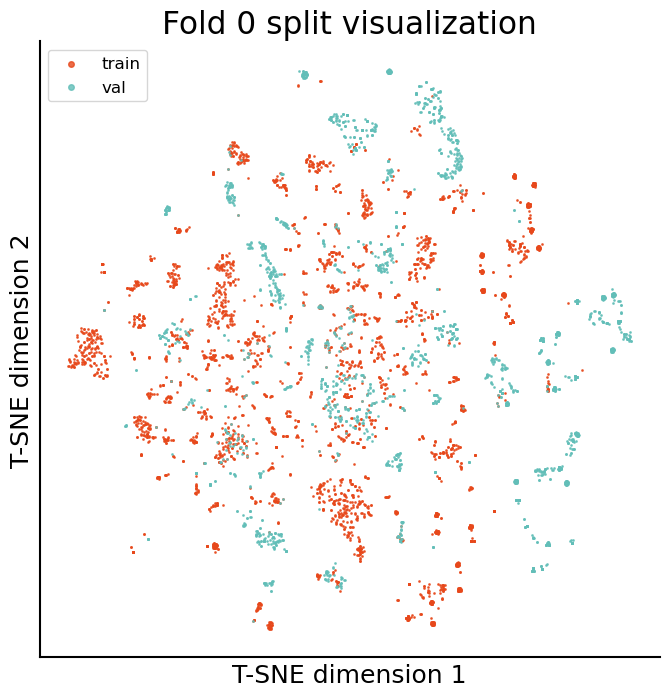

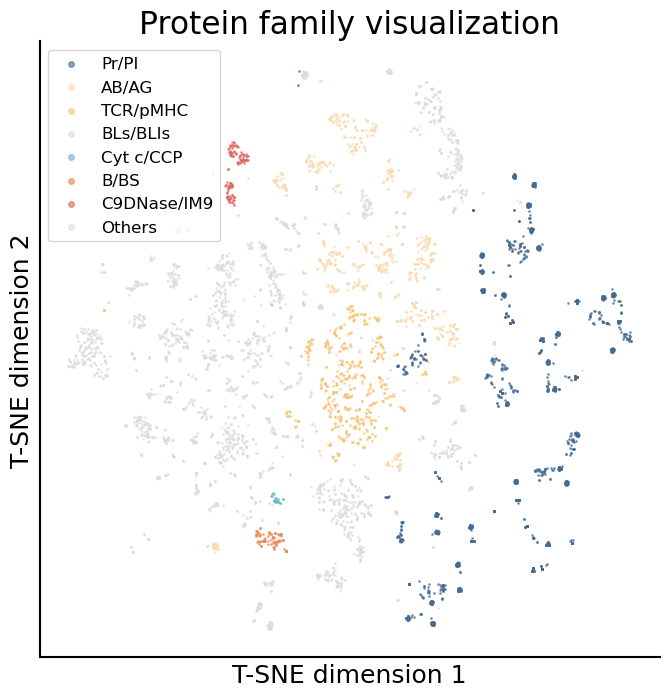

In [1]:

import pickle
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

# colors = [
#     '#A8D0E6',
#     '#F9D6A1',  
#     '#B4E7B3', 
#     '#F4A7B9', 
#     '#D1A7D8',   
#     '#E0E0E0',  
#     '#C2A79D',  
#     '#C7D8A7',  
#     "#3CB371",  
#     "#D2691E"
# ]
colors = [
'#E7481B',  
'#62BEB8',  
]


colors2 = [
    "#DB645D", 
    "#E78555", 
    "#F7C376", 
    "#FADBB0", 
    "#6BB2C8", 
    "#436A92", 
    "#726FAC", 

    # "#D8A7A1", 
    # "#8C3B3B",  
    # "#A5A5A5", 
    # "#D9B38C",  
    # '#BF9CB1',
    "#B5D8C1", 
    '#DBDCDE',  
]


with open("./datasets/SKEMPIv2/interface_iDist_embed.pkl", "rb") as f:
    loaded_embeddings = pickle.load(f)

df_orig = pd.read_csv('./datasets/SKEMPIv2/labels/skempi_v2_new.csv')
proteins = [i.split('_')[0] for i in list(df_orig['#Pdb'])]
df_orig['Protein'] = proteins
label_legends = ['Train', 'Val']

label_dir = './datasets/SKEMPIv2/splits/skempi_v2_resplit_3fold.csv'
df = pd.read_csv(label_dir)
# unique_labels = list(df['fold_0'])

embeddings = []
clean_labels = []
pdb_list = []
family_list = []
nan = 0
print(len(loaded_embeddings))

hold_out_dict = {}
for i, row in df_orig.iterrows():
    hold_out = row['Hold_out_proteins'].split(',')
    hold_out = sorted(hold_out)
    protein = row['Protein']
    if 'TCR/pMHC' in hold_out:
        hold_out_dict[protein] = 'TCR/pMHC'
    elif 'Pr/PI' in hold_out:
        hold_out_dict[protein] = 'Pr/PI'
    elif 'AB/AG' in hold_out:
        hold_out_dict[protein] = 'AB/AG'
    else:
        hold_out_dict[protein] = ','.join(hold_out)
set_size_dict = {}
for key in hold_out_dict:
    hold_out = hold_out_dict[key]
    if hold_out not in set_size_dict:
        set_size_dict[hold_out] = 1
    else:
        set_size_dict[hold_out] += 1
sort_sizes = sorted(set_size_dict.items(), key=lambda item: item[1], reverse=True)
print(sort_sizes)

for i, key in enumerate(loaded_embeddings):
    # print(key, loaded_embeddings[key])
    # print(key[:-4])
    pdb = key.split('_')[0]
    label = list(df[df['Protein'] == pdb]['fold_1'])[0]
    # label = list(df['fold_1'])[i]
    hold_out_seq = list(df_orig[df_orig['Protein'] == pdb]['Hold_out_proteins'])[0]
    hold_out = list(df_orig[df_orig['Protein'] == pdb]['Hold_out_proteins'])[0].split(',')
    
    # if pdb in pdb_list:
    #     continue
    if not np.isnan(loaded_embeddings[key]).any():  
        embeddings.append(loaded_embeddings[key])
        clean_labels.append(label)
        pdb_list.append(pdb)
        if 'TCR/pMHC' in hold_out:
            family_list.append('TCR/pMHC')
        elif 'Pr/PI' in hold_out:
            family_list.append('Pr/PI')
        elif 'AB/AG' in hold_out:
            family_list.append('AB/AG')
        elif set_size_dict[','.join(sorted(hold_out))] >= 6:  
            family_list.append(','.join(sorted(hold_out)))
        else:
            family_list.append('Others')
    else:
        nan += 1
print("Found Nan!", nan)
    
loaded_embeddings = np.vstack(embeddings)

# umap_model = umap.UMAP(n_components=2, random_state=2025)
# reduced_embeddings = umap_model.fit_transform(loaded_embeddings)
tsne = TSNE(n_components=2, random_state=2025)
reduced_embeddings = tsne.fit_transform(loaded_embeddings)
print(reduced_embeddings.shape)

# labels = [1] * len(all_embeddings)

family2name = {'1B2S_A_D': 'Barnase', '1JTD_A_B': 'Beta-lactamases', '1EMV_A_B': 'COLICIN-E9', '2B0Z_A_B': 'Cytochrome c'}
plt.figure(0, figsize=(8, 8))
ax = plt.gca()
for idx, label in enumerate(['train', 'val']):
    indices = [i for i, x in enumerate(clean_labels) if x == label]
    print("Indices:", label, len(indices))
    plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], alpha=0.8, label=label, color=colors[idx], s=1)
plt.legend(markerscale=4, loc='upper left', fontsize=12)
plt.title("Fold 0 split visualization", fontsize=22.5)
plt.xticks([])
plt.yticks([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.xlabel('T-SNE dimension 1', fontsize=18)
plt.ylabel('T-SNE dimension 2', fontsize=18)
# plt.savefig('./fig2/iDistEmbed_split_byMut.jpg', dpi=400)
plt.figure(1, figsize=(8, 8))
ax = plt.gca()
scatters = {}
indices = [i for i, x in enumerate(family_list) if x == 'Others']
scatter = plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], alpha=0.6, label='Others', color=colors2[-1], s=1)
scatters['Others'] = scatter
for idx, label in enumerate(set(family_list)):
    if label == 'Others':
        continue
    indices = [i for i, x in enumerate(family_list) if x == label]
    print("Indices:", label, len(indices))
    if len(label.split(',')) > 1:
        plot_label = family2name[label.split(',')[0]]
    else:
        plot_label = label
    scatter = plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], alpha=0.6, label=plot_label, color=colors2[idx], s=1)
    scatters[plot_label] = scatter
# plt.legend(handles = [scatters['Pr/PI'], scatters['AB/AG'], scatters['TCR/pMHC'], scatters['Beta-lactamases'], scatters['Cytochrome c'], scatters['Barnase'], scatters['COLICIN-E9'], scatters['Others']], labels = ['Pr/PI', 'AB/AG', 'TCR/pMHC', 'BLs/BLIs', 'Cyt c/CCP', 'B/BS', 'C9DNase/IM9', 'Others'], markerscale=4, loc='upper left', fontsize=12)
plt.legend(handles = [scatters['Pr/PI'], scatters['AB/AG'], scatters['TCR/pMHC'], scatters['Beta-lactamases'], scatters['Cytochrome c'], scatters['Barnase'], scatters['COLICIN-E9'], scatters['Others']], labels = ['Pr/PI', 'AB/AG', 'TCR/pMHC', 'BLs/BLIs', 'Cyt c/CCP', 'B/BS', 'C9DNase/IM9', 'Others'], markerscale=4, loc='upper left', fontsize=12)
plt.title("Protein family visualization", fontsize=15)
plt.xticks([])
plt.yticks([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.xlabel('T-SNE dimension 1', fontsize=12)
plt.ylabel('T-SNE dimension 2', fontsize=12)
# plt.savefig('./fig2/iDistEmbed_split_byFamily.jpg', dpi=400)
plt.show()


5820
Found Nan! 71
(6255, 2)
Indices: SKEMPIv2 5749
5748
Indices: TCR-MHC 87
5835
Indices: HER2 419
6254


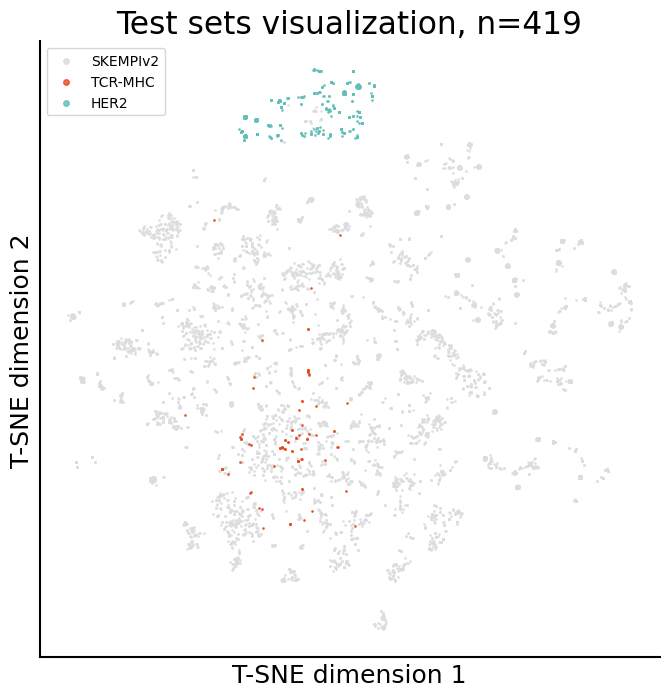

In [3]:
# Fig2-embedding visualization
import pickle
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

colors = [
    '#A8D0E6', 
    '#F9D6A1',  
    '#B4E7B3',  
    '#F4A7B9',  
    '#D1A7D8', 
    '#E0E0E0',  
    '#C2A79D',  
    '#C7D8A7', 
    "#3CB371",  
    "#D2691E"
]

colors2 = [
    '#DBDCDE',  # 灰色
    '#E7481B',  
    '#62BEB8', 
    
]

with open("./datasets/SKEMPIv2/interface_iDist_embed.pkl", "rb") as f:
    loaded_embeddings = pickle.load(f)
    
with open("./datasets/TCR-MHC/interface_iDist_embed.pkl", "rb") as f:
    loaded_embeddings_tcr = pickle.load(f)
    
with open("./datasets/HER2/interface_iDist_embed.pkl", "rb") as f:
    loaded_embeddings_her2 = pickle.load(f)

df_orig = pd.read_csv('./datasets/SKEMPIv2/labels/skempi_v2_new.csv')
proteins = [i.split('_')[0] for i in list(df_orig['#Pdb'])]
df_orig['Protein'] = proteins
label_legends = ['Train', 'Val']

label_dir = './datasets/SKEMPIv2/splits/skempi_v2_mutsplit_3fold.csv'
her2_dir = './datasets/HER2/splits/HER2_test.csv'
tcr_dir = './datasets/TCR-MHC/splits/TCR_MHC_test_noskempi.csv'
df = pd.read_csv(label_dir)
her2_df = pd.read_csv(her2_dir)
her2_toplot = list(her2_df['Protein'])

tcr_df = pd.read_csv(tcr_dir)
tcr_toplot = list(tcr_df['Protein'])
# unique_labels = list(df['fold_0'])
embeddings = []
clean_labels = []
pdb_list = []
nan = 0
print(len(loaded_embeddings))


for i, key in enumerate(loaded_embeddings):
    # print(key, loaded_embeddings[key])
    # print(key[:-4])
    pdb = key.split('_')[0]
    # label = list(df[df['Protein'] == pdb]['fold_1'])[0]

    # if pdb in pdb_list:
    #     continue
    if not np.isnan(loaded_embeddings[key]).any():  
        embeddings.append(loaded_embeddings[key])
        clean_labels.append("SKEMPIv2")
        pdb_list.append(pdb)
    else:
        nan += 1
        


for i, key in enumerate(loaded_embeddings_tcr):
    # print(key, loaded_embeddings[key])
    # print(key[:-4])
    pdb = key.split('_')[0]
    # print(pdb)
    if pdb not in tcr_toplot:
        continue
    # label = list(df[df['Protein'] == pdb]['fold_1'])[0]
    
    # if pdb in pdb_list:
    #     continue
    if not np.isnan(loaded_embeddings_tcr[key]).any():  
        embeddings.append(loaded_embeddings_tcr[key])
        clean_labels.append("TCR-MHC")
        pdb_list.append(pdb)
    else:
        nan += 1

for i, key in enumerate(loaded_embeddings_her2):
    # print(key, loaded_embeddings[key])
    # print(key[:-4])
    pdb = key.split('_')[0]
    # print(pdb)
    if pdb not in her2_toplot:
        continue
    # label = list(df[df['Protein'] == pdb]['fold_1'])[0]
    
    # if pdb in pdb_list:
    #     continue
    if not np.isnan(loaded_embeddings_her2[key]).any():  
        embeddings.append(loaded_embeddings_her2[key])
        clean_labels.append("HER2")
        pdb_list.append(pdb)
    else:
        nan += 1
print("Found Nan!", nan)
    
loaded_embeddings = np.vstack(embeddings)

# umap_model = umap.UMAP(n_components=2, random_state=2025)
# reduced_embeddings = umap_model.fit_transform(loaded_embeddings)
tsne = TSNE(n_components=2, random_state=2025)
reduced_embeddings = tsne.fit_transform(loaded_embeddings)
print(reduced_embeddings.shape)

# labels = [1] * len(all_embeddings)
plt.figure(0, figsize=(8, 8))
ax = plt.gca()
length = 0
for idx, label in enumerate(['SKEMPIv2', 'TCR-MHC', 'HER2']):
    indices = [i for i, x in enumerate(clean_labels) if x == label]
    print("Indices:", label, len(indices))
    length = len(indices)
    print(max(indices))
    plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], alpha=0.8, label="{}, n={}".format(label, length), color=colors2[idx], s=1)
plt.legend(markerscale=4, loc='upper left')
# plt.title("T-SNE visualization of HER2 embeddings, n={}".format(length), fontsize=15)
plt.title("Test sets visualization", fontsize=22.5)
plt.xticks([])
plt.yticks([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.xlabel('T-SNE dimension 1', fontsize=18)
plt.ylabel('T-SNE dimension 2', fontsize=18)
plt.savefig('./fig2/iDistEmbed_split_test_sets.jpg', dpi=400)
plt.show()